# Injectivity (Monotonicity) Constraint Toggle — Comparison

Compares correction results across four modes:
1. **Jdet only** — gradient-based Jacobian determinant constraint
2. **Jdet + Shoelace** — also enforce positive geometric quad-cell areas
3. **Jdet + Injectivity** — also enforce monotonicity of deformed coordinates (sufficient for global injectivity on structured grids)
4. **Jdet + Shoelace + Injectivity** — all three constraints combined

**Monotonicity constraint:** For a structured grid with unit spacing, global injectivity is guaranteed when:
- `def_x[i, j+1] > def_x[i, j]` (x increases along rows)
- `def_y[i+1, j] > def_y[i, j]` (y increases along columns)

This is a sufficient (but not necessary) condition — more restrictive than Jacobian or shoelace alone, and may increase L2 error.

In [ ]:
import numpy as np
import time

from dvfopt import (
    iterative_parallel,
    jacobian_det2D,
    shoelace_det2D,
)
from dvfopt.jacobian import _monotonicity_diffs_2d
from dvfopt.viz import (
    plot_grid_before_after,
    plot_checkerboard_before_after,
    plot_neg_jdet_neighborhoods,
)
from test_cases import (
    SYNTHETIC_CASES,
    make_deformation,
)

## Helper: run all four modes and compare

In [ ]:
from dvfopt._defaults import DEFAULT_PARAMS

JDET_THRESHOLD = DEFAULT_PARAMS["threshold"]
ERR_TOL = DEFAULT_PARAMS["err_tol"]

MODES = [
    ("jdet-only",         dict(enforce_shoelace=False, enforce_injectivity=False)),
    ("jdet+shoe",         dict(enforce_shoelace=True,  enforce_injectivity=False)),
    ("jdet+inject",       dict(enforce_shoelace=False, enforce_injectivity=True)),
    ("jdet+shoe+inject",  dict(enforce_shoelace=True,  enforce_injectivity=True)),
]


def summarize(label, deformation, phi):
    """Print Jacobian, shoelace, and monotonicity stats (interior only)."""
    jac = jacobian_det2D(phi)
    shoe = shoelace_det2D(phi)
    h_mono, v_mono = _monotonicity_diffs_2d(phi[0], phi[1])
    phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
    n_neg_jac = int((jac[0, 1:-1, 1:-1] <= 0).sum())
    n_neg_shoe = int((shoe[0, 1:-1, 1:-1] <= 0).sum())
    min_jac = float(jac[0, 1:-1, 1:-1].min())
    min_shoe = float(shoe[0, 1:-1, 1:-1].min())
    # Interior monotonicity: h_mono is (H, W-1), v_mono is (H-1, W)
    # Exclude outer ring: h_mono[1:-1, 1:-1], v_mono[1:-1, 1:-1]
    min_h = float(h_mono[1:-1, 1:-1].min())
    min_v = float(v_mono[1:-1, 1:-1].min())
    mono_ok = min_h >= JDET_THRESHOLD - ERR_TOL and min_v >= JDET_THRESHOLD - ERR_TOL
    print(f"  [{label:20s}]  neg_jdet={n_neg_jac}  min_jdet={min_jac:+.4f}"
          f"  neg_shoe={n_neg_shoe}  min_shoe={min_shoe:+.4f}"
          f"  min_h={min_h:+.4f}  min_v={min_v:+.4f}"
          f"  mono={'OK' if mono_ok else 'FAIL'}  L2={l2:.4f}")
    return dict(n_neg_jac=n_neg_jac, n_neg_shoe=n_neg_shoe,
                min_jac=min_jac, min_shoe=min_shoe,
                min_h=min_h, min_v=min_v, mono_ok=mono_ok, l2=l2)


def compare(key, deformation):
    """Run correction in all four modes and visualise."""
    print(f"\n{'='*80}")
    print(f"  {key}  |  shape={deformation.shape[-2:]}")
    print(f"{'='*80}")

    # Initial stats (interior only)
    phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
    jac0 = jacobian_det2D(phi_init)
    shoe0 = shoelace_det2D(phi_init)
    h0, v0 = _monotonicity_diffs_2d(phi_init[0], phi_init[1])
    print(f"  [initial]  neg_jdet={int((jac0[0, 1:-1, 1:-1] <= 0).sum())}  min_jdet={float(jac0[0, 1:-1, 1:-1].min()):+.4f}"
          f"  neg_shoe={int((shoe0[0, 1:-1, 1:-1] <= 0).sum())}  min_shoe={float(shoe0[0, 1:-1, 1:-1].min()):+.4f}"
          f"  min_h={float(h0[1:-1, 1:-1].min()):+.4f}  min_v={float(v0[1:-1, 1:-1].min()):+.4f}")

    results = {}
    for label, kwargs in MODES:
        t0 = time.perf_counter()
        phi = iterative_parallel(
            deformation.copy(), verbose=1, threshold=JDET_THRESHOLD, **kwargs,
        )
        elapsed = time.perf_counter() - t0
        stats = summarize(label, deformation, phi)
        stats["time"] = elapsed
        print(f"  Time: {elapsed:.2f}s")
        results[label] = (phi, stats)

    # Visualisations — grid comparison for each mode
    for label, (phi, stats) in results.items():
        plot_grid_before_after(deformation, phi, title=f"{key} — {label}")

    return results

## Synthetic test cases


  01a_10x10_crossing  |  shape=(10, 10)
  [initial]  neg_jdet=9  min_jdet=-1.0246  neg_shoe=10  min_shoe=-0.7716  min_h=-1.4773  min_v=+0.9952
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.024567
[iter    1]  serial  fix (  3,  5)  neg_pixels=9
         -> neg_jdet     0  min_jdet +0.010000  L2 2.2706  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      9 ->     0
  Min Jdet  -1.024567 -> +0.010000
  L2 error         : 2.270564
  Time             : 0.14s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=4  min_shoe=-0.9718  min_h=-1.9560  min_v=-0.0183  mono=FAIL  L2=2.2706
  Time: 0.14s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixel

c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\modules\dvfviz.py:842: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1])


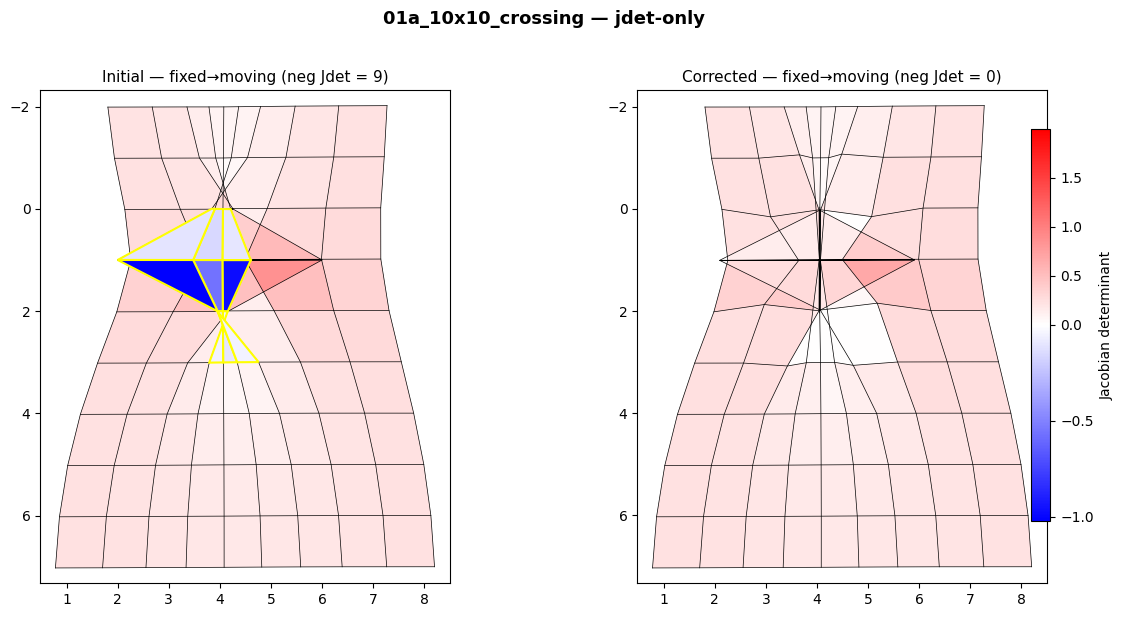

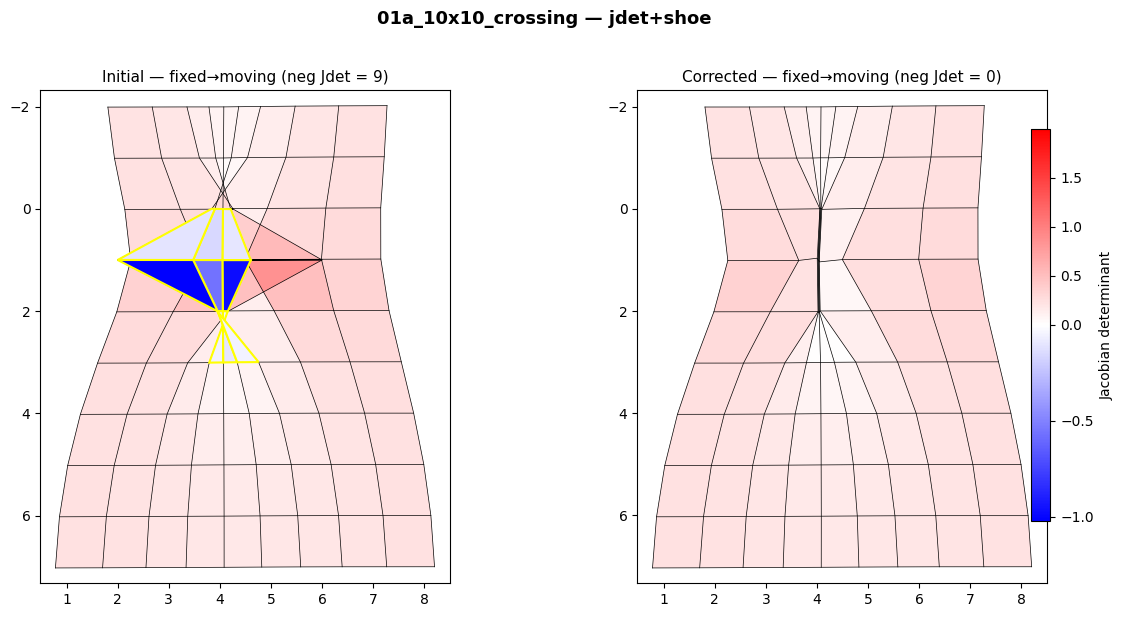

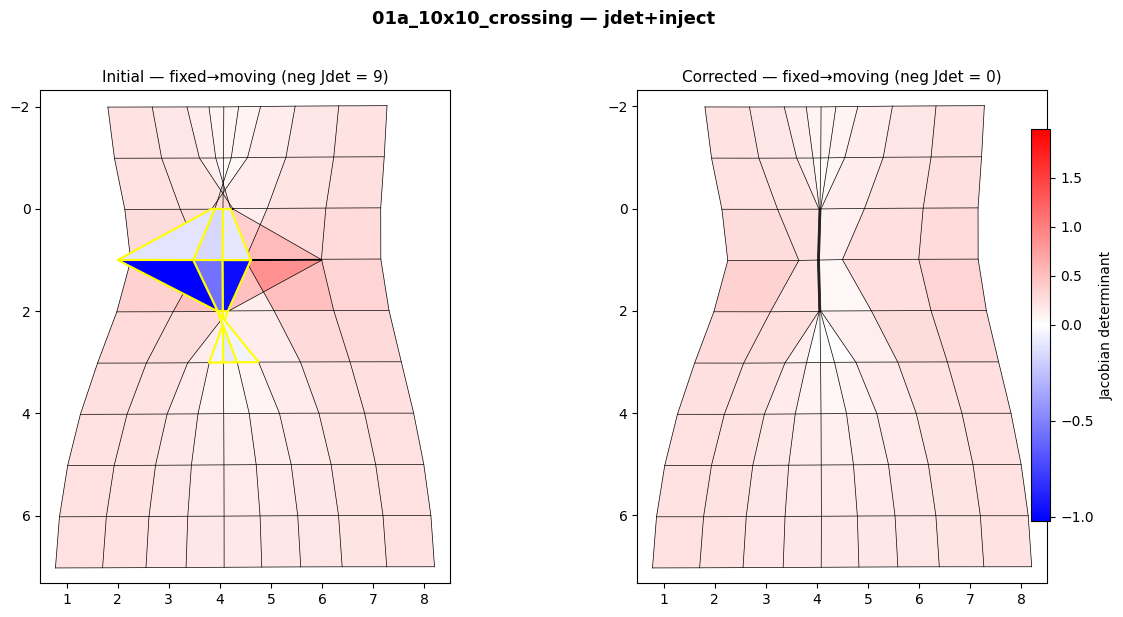

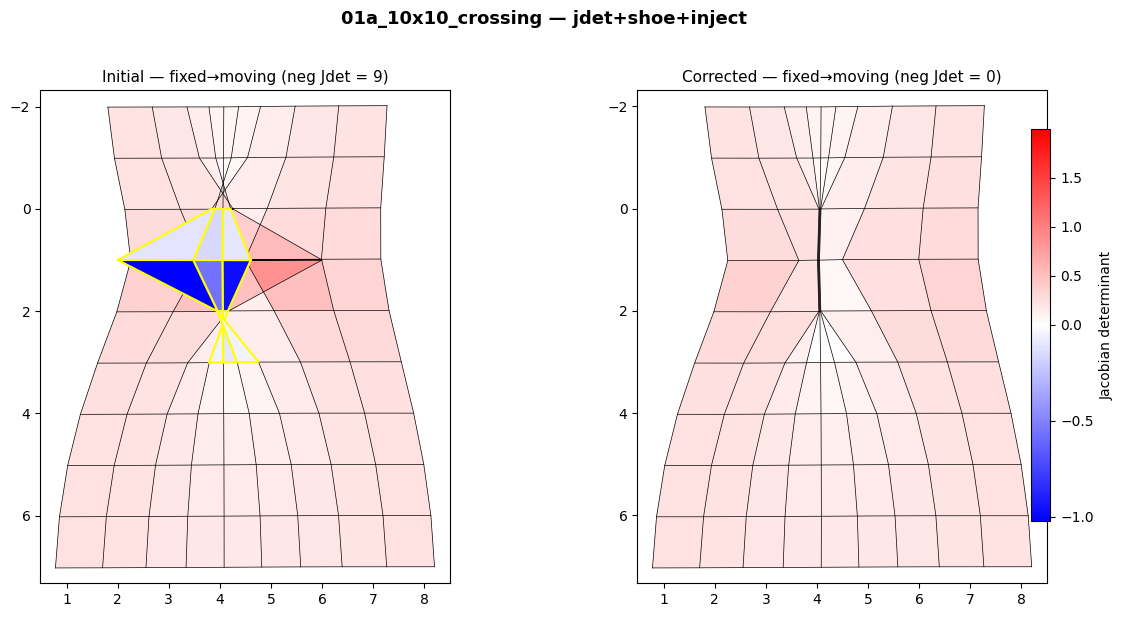


  01b_10x10_opposite  |  shape=(10, 10)
  [initial]  neg_jdet=4  min_jdet=-0.7304  neg_shoe=3  min_shoe=-0.4550  min_h=-0.9459  min_v=+1.0000
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 6  |  min Jdet: -1.154032
[iter    1]  serial  fix (  2,  1)  neg_pixels=4
         -> neg_jdet     0  min_jdet +0.010000  L2 1.4622  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      6 ->     0
  Min Jdet  -1.154032 -> +0.010000
  L2 error         : 1.462154
  Time             : 0.15s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=0  min_shoe=+0.0221  min_h=-0.3824  min_v=+0.7505  mono=FAIL  L2=1.4622
  Time: 0.15s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels

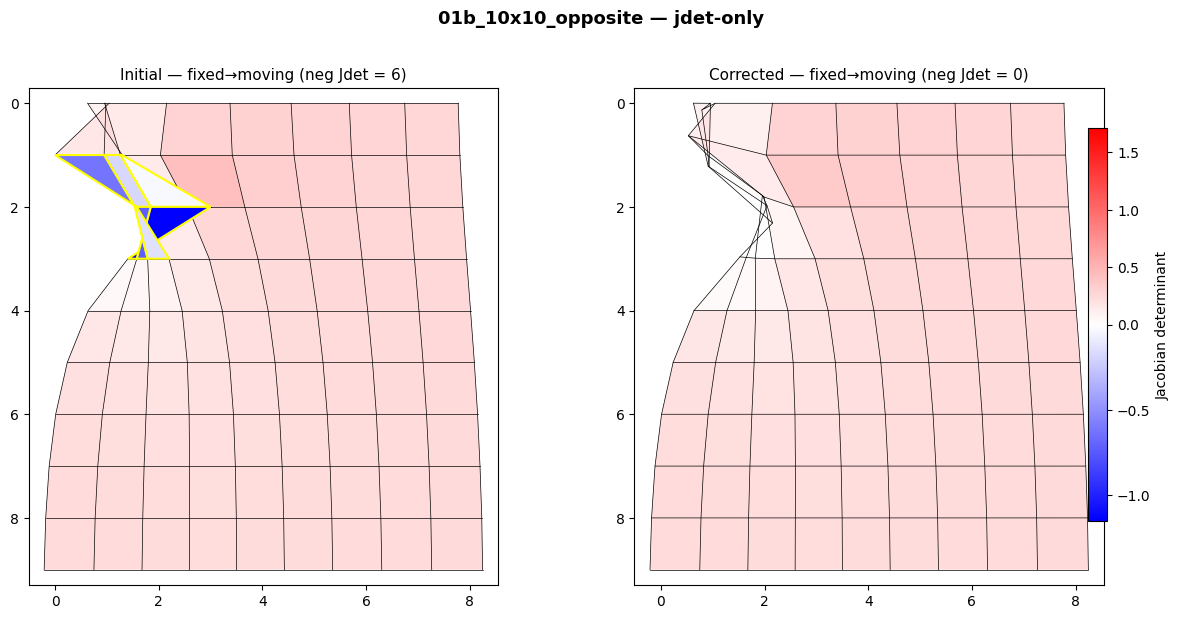

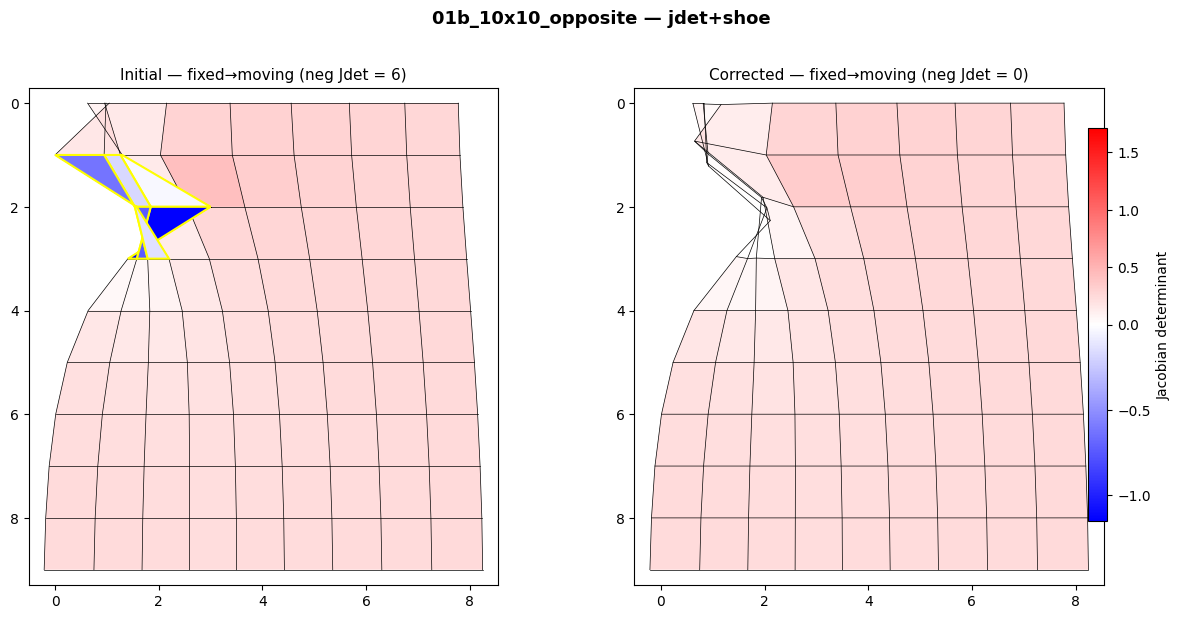

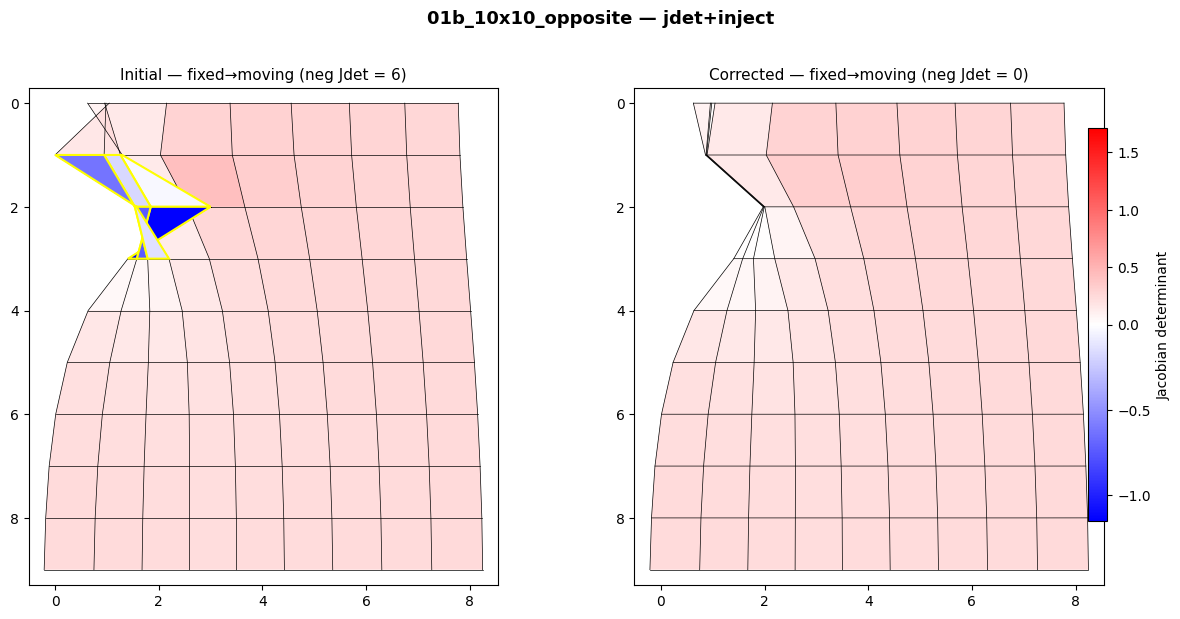

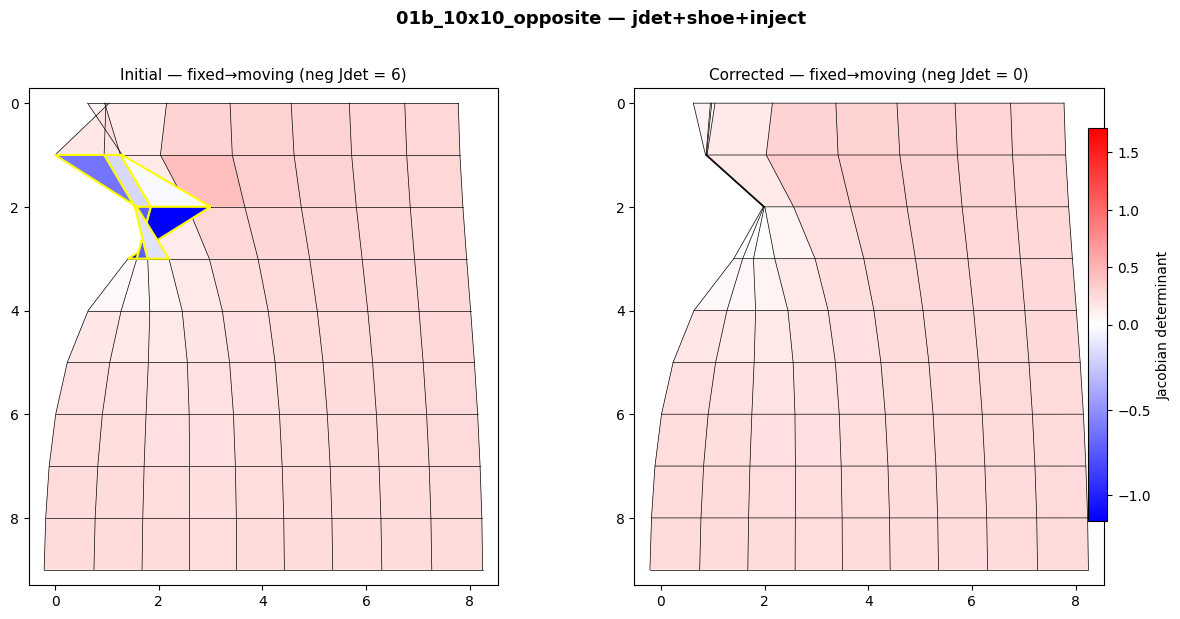


  01c_20x40_edges  |  shape=(20, 40)
  [initial]  neg_jdet=26  min_jdet=-1.3430  neg_shoe=32  min_shoe=-1.8746  min_h=-2.0808  min_v=-1.5018
[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 29  |  min Jdet: -1.343039
[iter    1]  parallel  batch=5  neg_pixels=26  windows=9-9
         -> neg_jdet     3  min_jdet -0.321936  L2 2.8895
[iter    2]  parallel  batch=2  neg_pixels=3  windows=11-11
         -> neg_jdet     5  min_jdet -0.279748  L2 2.8535
  [escalate] parallel didn't improve (3->5), global min window -> 11
[iter    3]  serial  fix (  3, 32)  neg_pixels=5
         -> neg_jdet     1  min_jdet -0.141972  L2 2.9417  win 11  sub-iters 1
[iter    4]  serial  fix ( 17, 24)  neg_pixels=1
         -> neg_jdet     0  min_jdet +0.010000  L2 2.9527  win 9  sub-iters 1
[done] All Jdet > threshold after iter 4

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 2

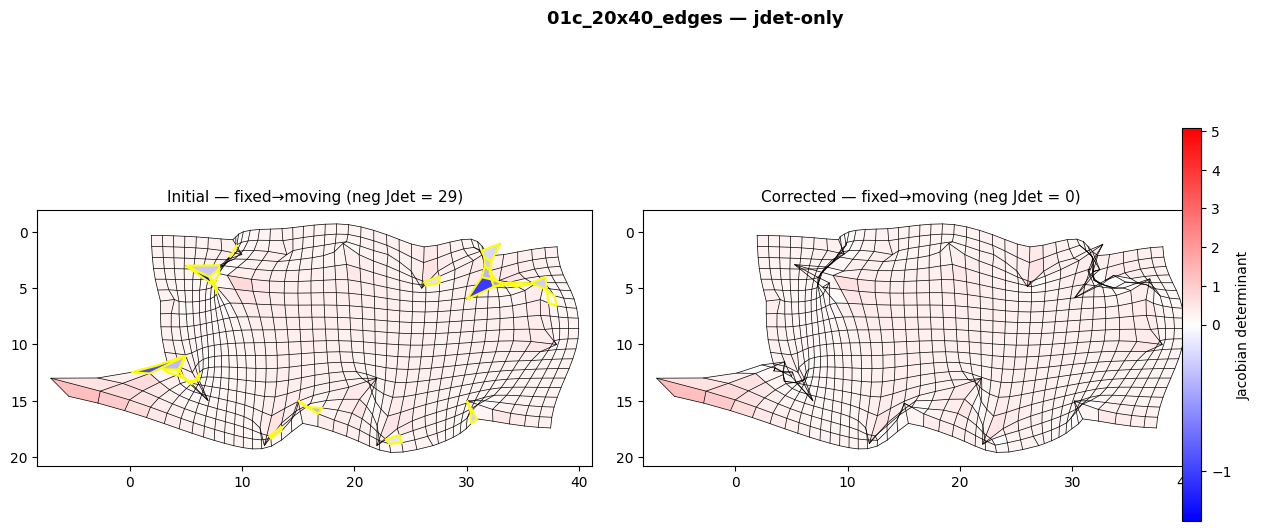

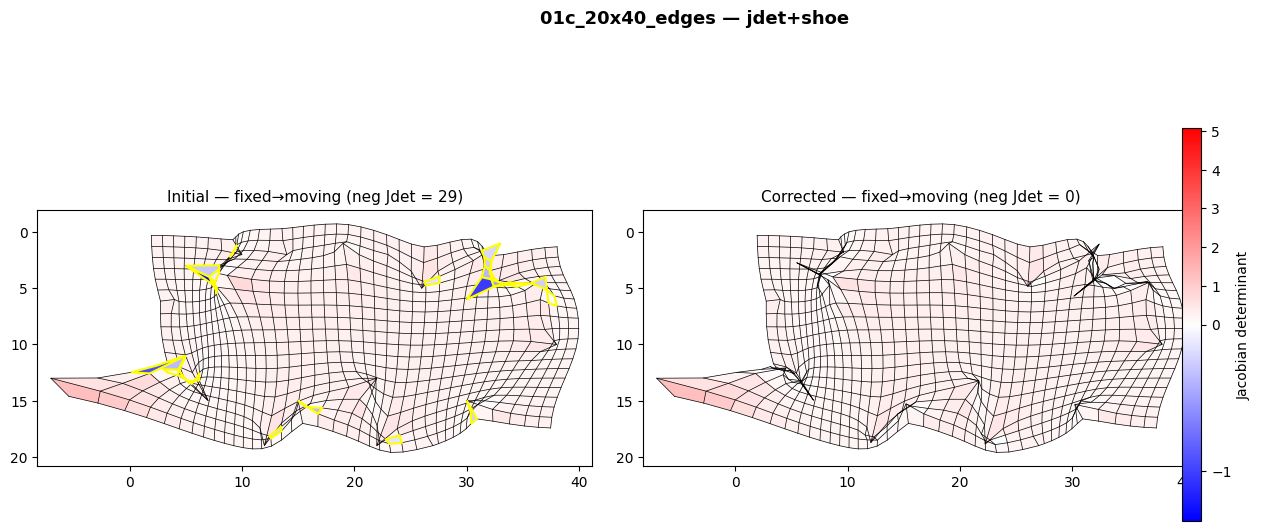

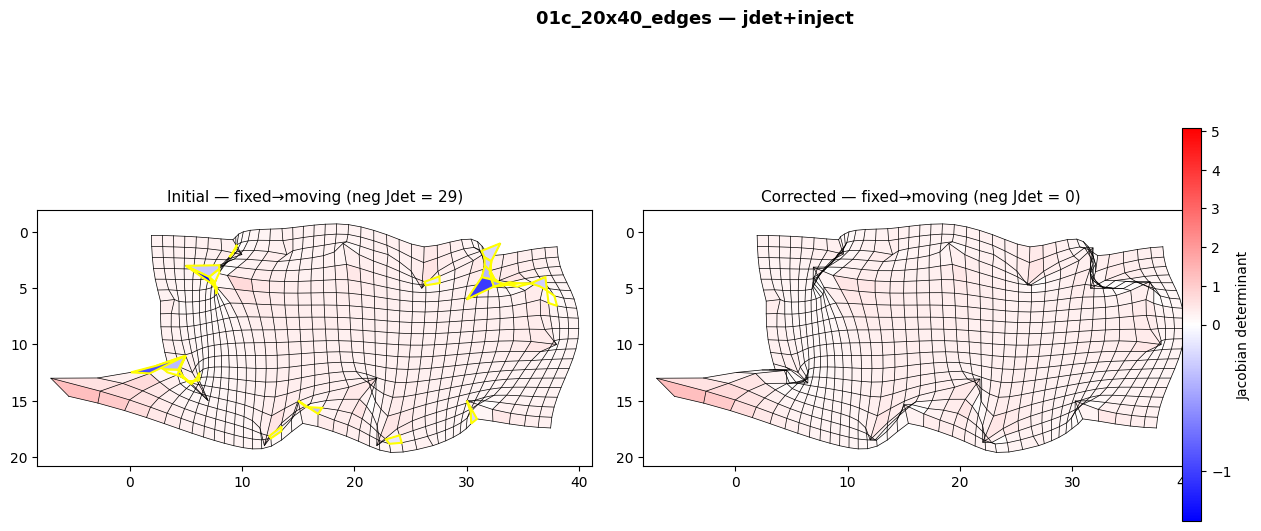

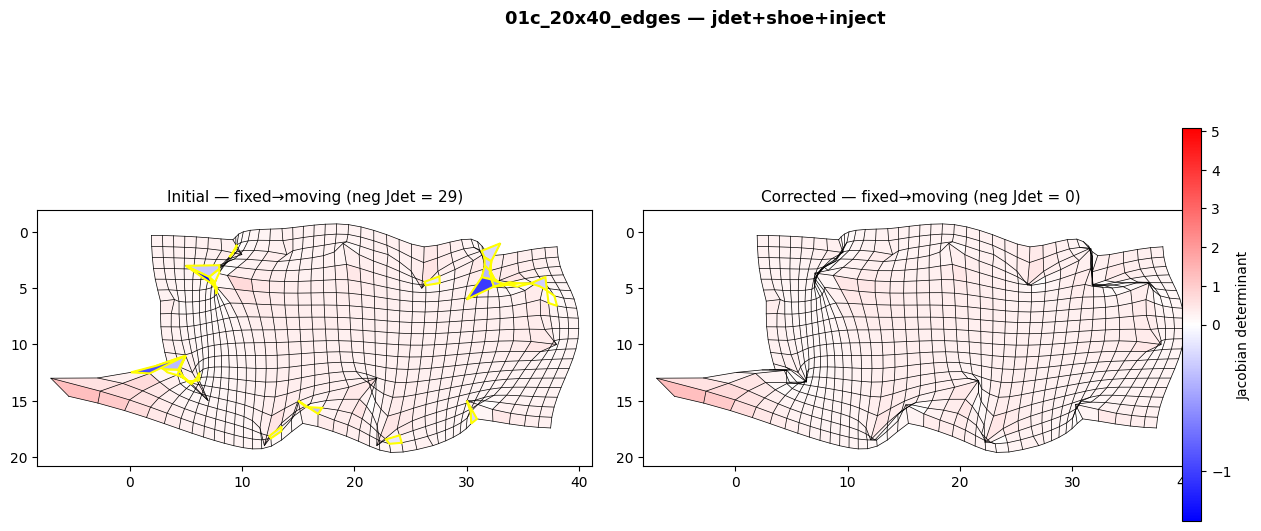


  01d_20x40_crossing  |  shape=(20, 40)
  [initial]  neg_jdet=141  min_jdet=-3.3699  neg_shoe=132  min_shoe=-2.9384  min_h=-4.7211  min_v=+0.7268
[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 158  |  min Jdet: -3.369923
[iter    1]  serial  fix ( 15, 11)  neg_pixels=142
         -> neg_jdet    84  min_jdet -3.309977  L2 8.9325  win 20  sub-iters 7
  [full-grid] Optimizing entire 20x40 grid (1600 variables)
         -> full-grid  neg_jdet     0  min_jdet +0.010000  L2 16.2774
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 20 x 40
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet    158 ->     0
  Min Jdet  -3.369923 -> +0.010000
  L2 error         : 16.277398
  Time             : 45.87s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=69  min_shoe=-3.6307  min_h=-4.6902  min_v=-1.4227  m

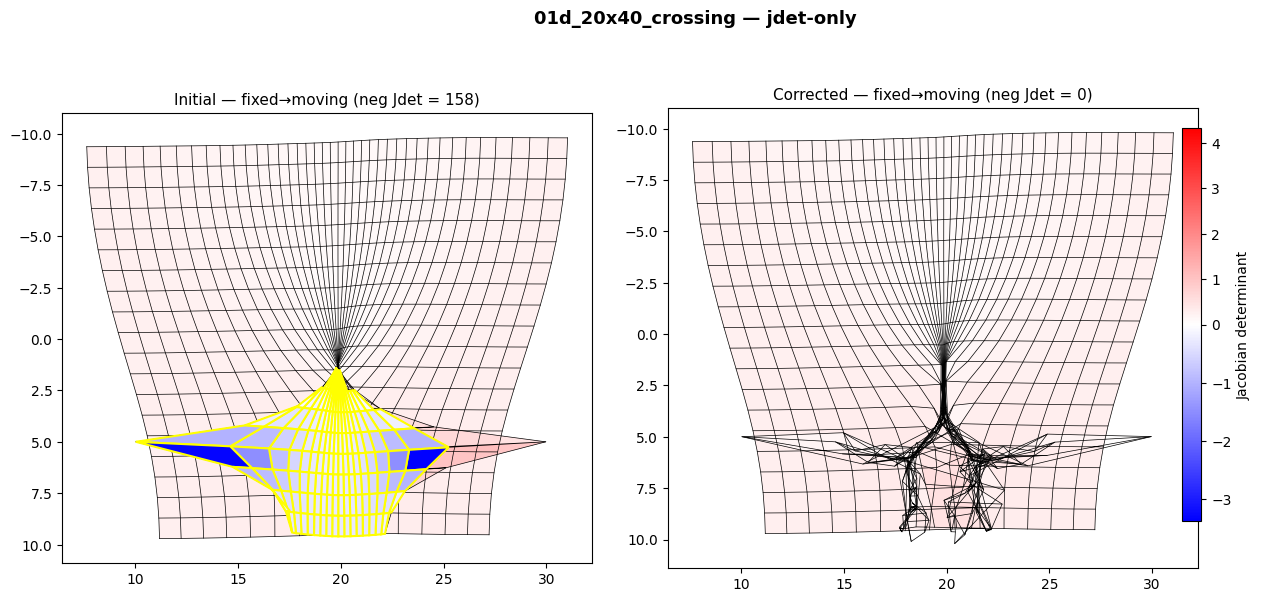

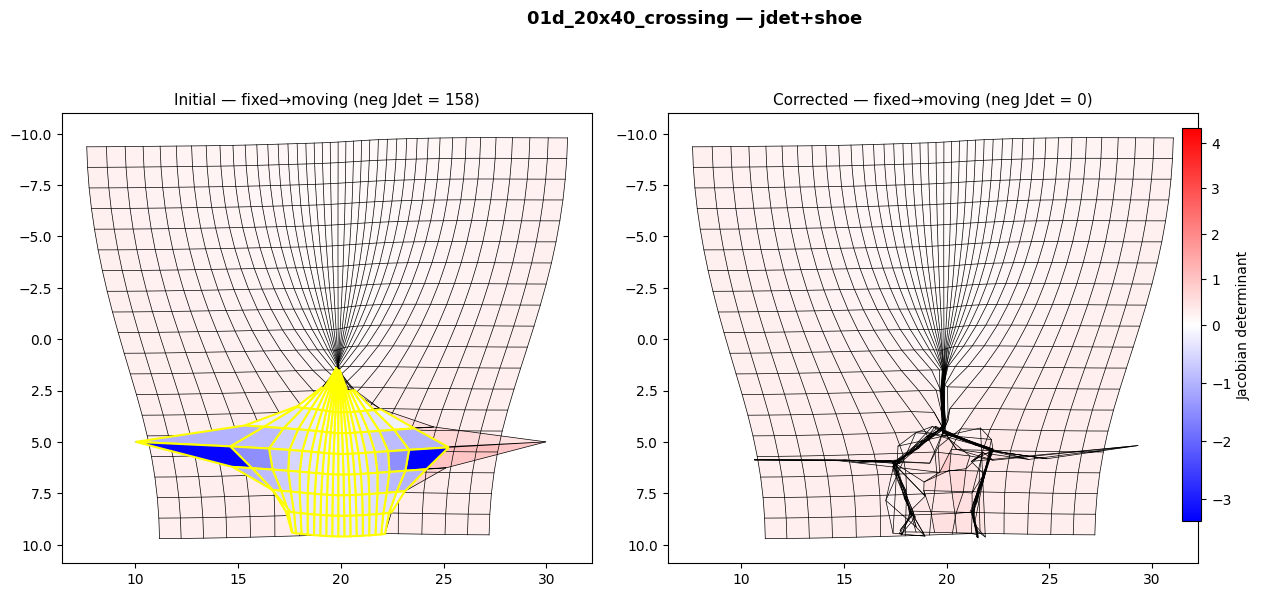

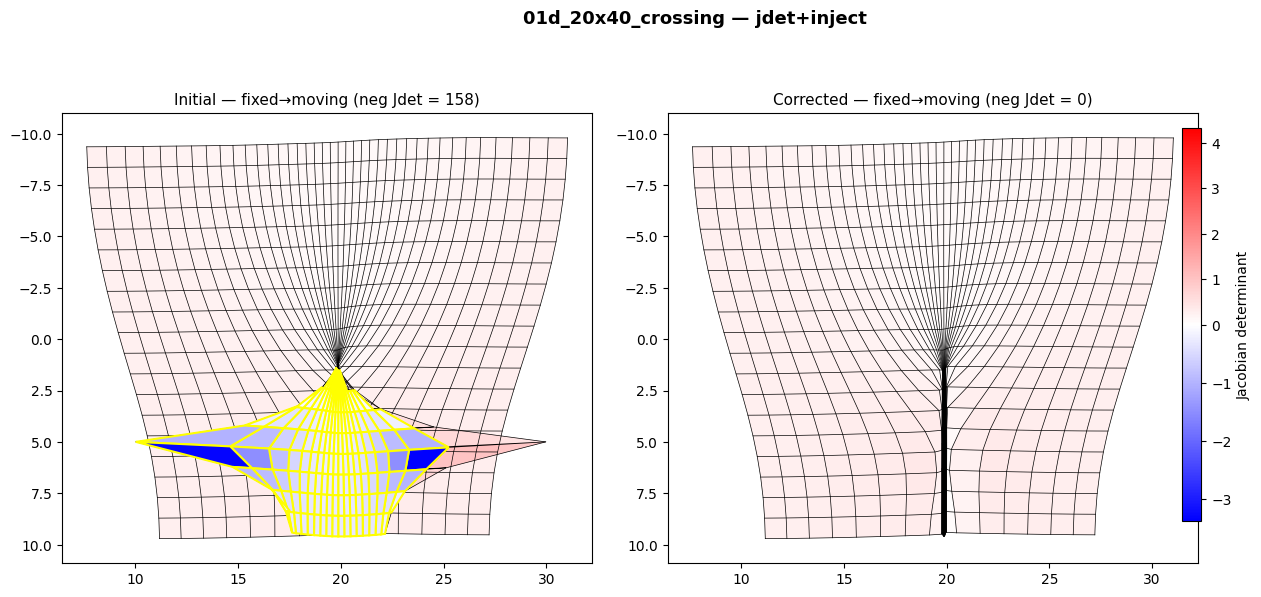

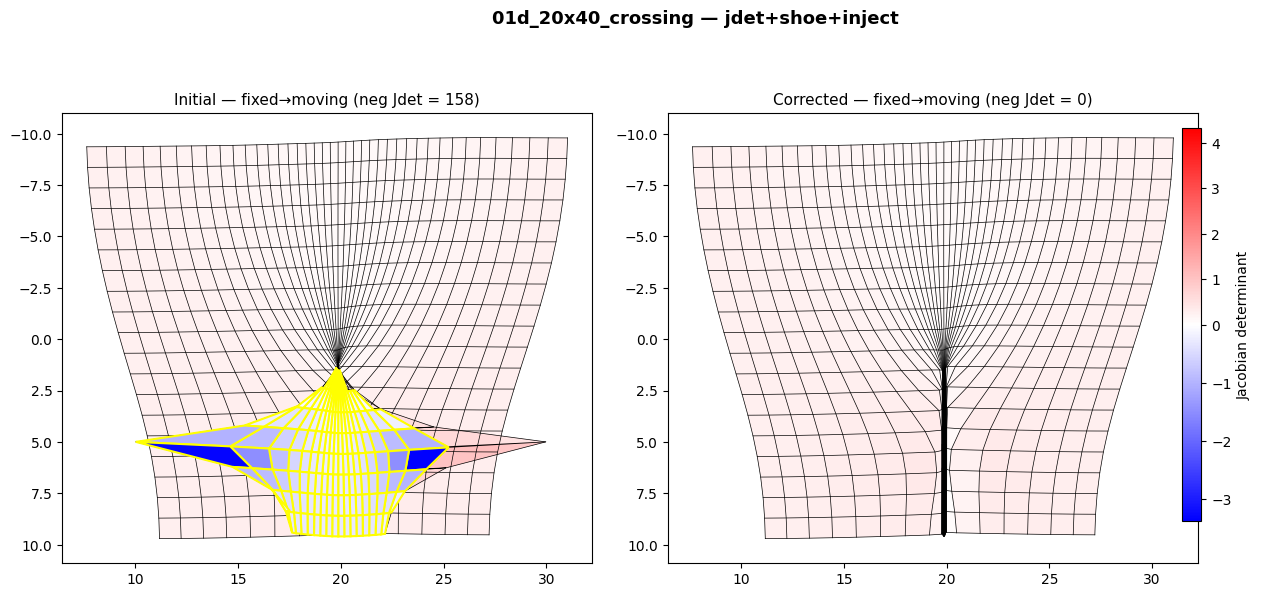


  03a_10x10_opposite  |  shape=(10, 10)
  [initial]  neg_jdet=9  min_jdet=-1.1289  neg_shoe=6  min_shoe=-0.8922  min_h=-1.6475  min_v=+1.0000
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 14  |  min Jdet: -1.128860
[iter    1]  serial  fix (  1,  3)  neg_pixels=9
         -> neg_jdet     0  min_jdet +0.010000  L2 1.7927  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet     14 ->     0
  Min Jdet  -1.128860 -> +0.010000
  L2 error         : 1.792742
  Time             : 0.13s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=4  min_shoe=-0.6928  min_h=-1.5933  min_v=+0.4493  mono=FAIL  L2=1.7927
  Time: 0.13s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixel

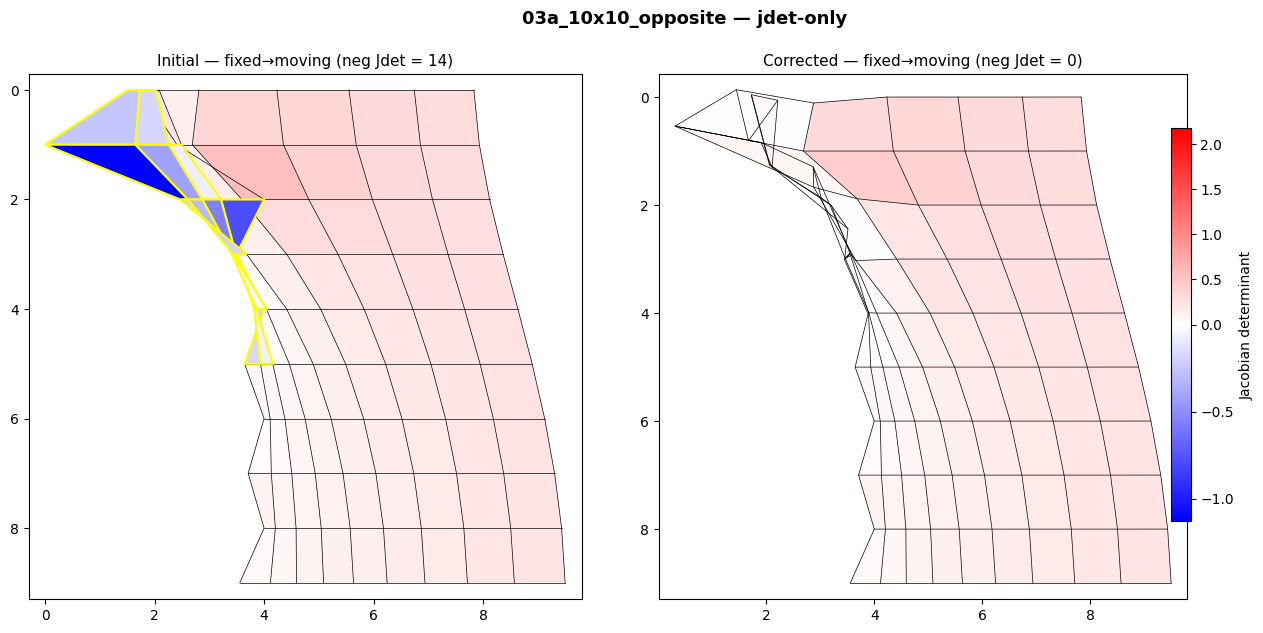

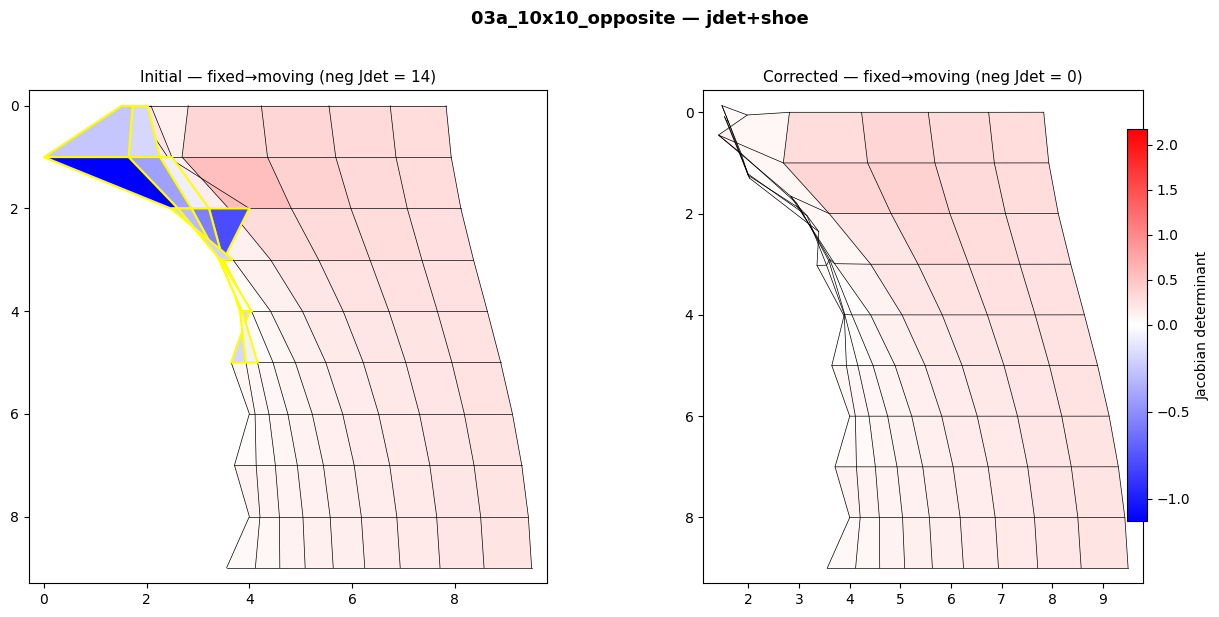

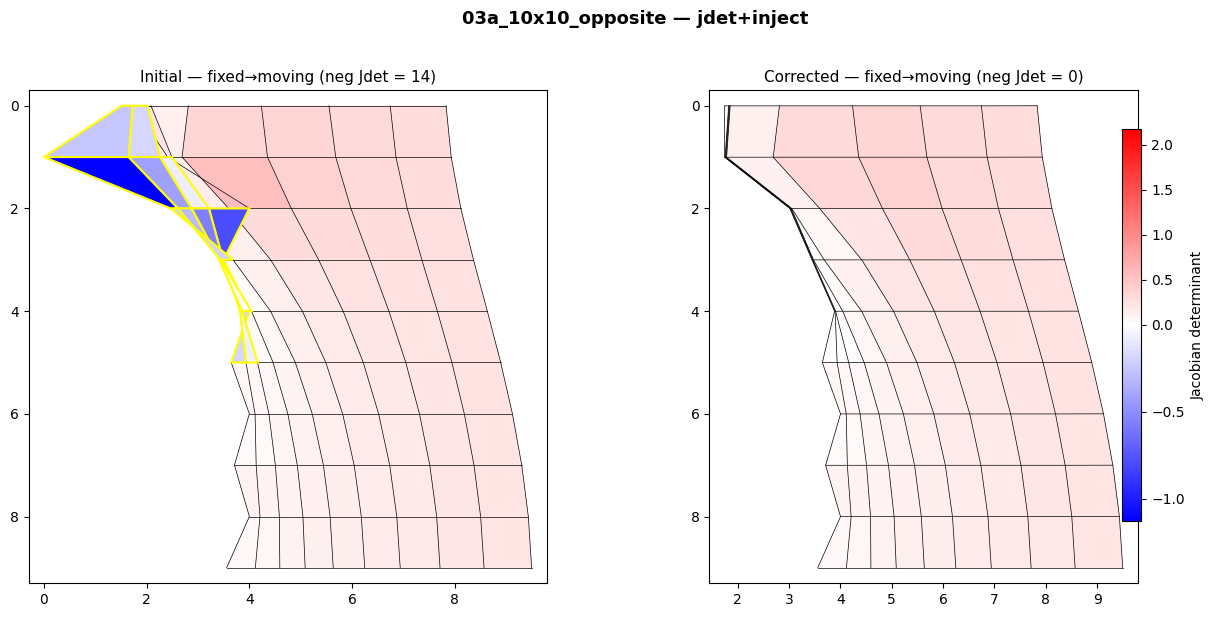

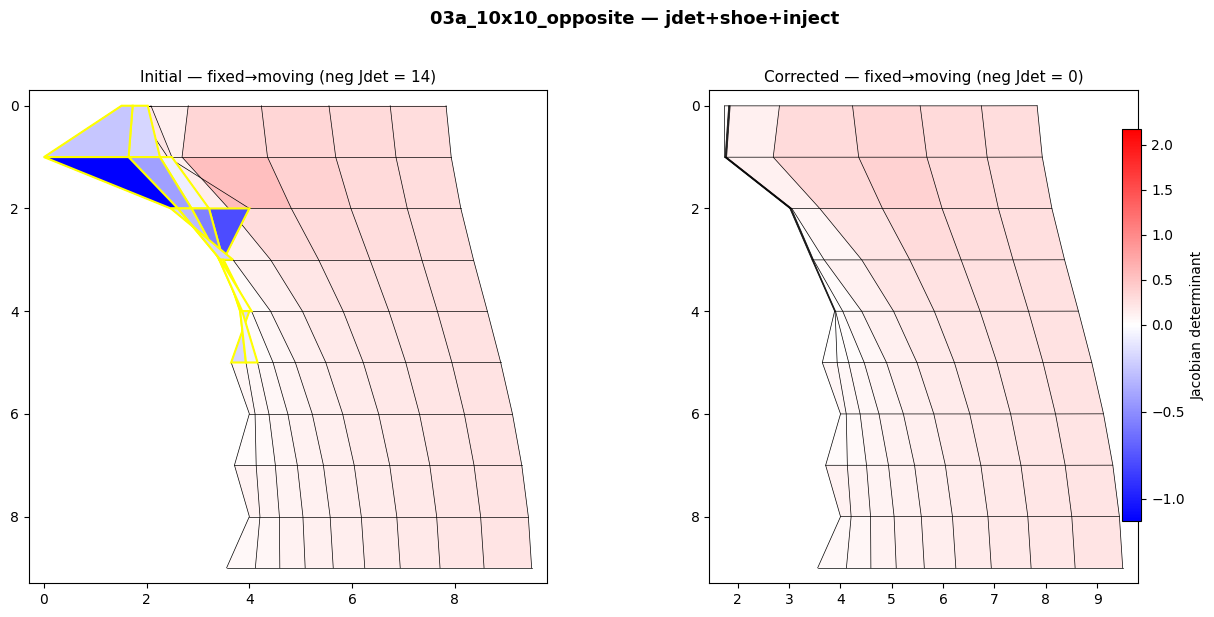


  03b_10x10_crossing  |  shape=(10, 10)
  [initial]  neg_jdet=8  min_jdet=-0.9905  neg_shoe=12  min_shoe=-0.5860  min_h=-1.3816  min_v=+0.9902
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 18  |  min Jdet: -1.047820
[iter    1]  serial  fix (  8,  2)  neg_pixels=8
         -> neg_jdet     0  min_jdet +0.010000  L2 3.7290  win 10  sub-iters 2
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet     18 ->     0
  Min Jdet  -1.047820 -> +0.010000
  L2 error         : 3.729008
  Time             : 0.93s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=12  min_shoe=-0.9637  min_h=-2.1209  min_v=-0.0681  mono=FAIL  L2=3.7290
  Time: 0.93s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pi

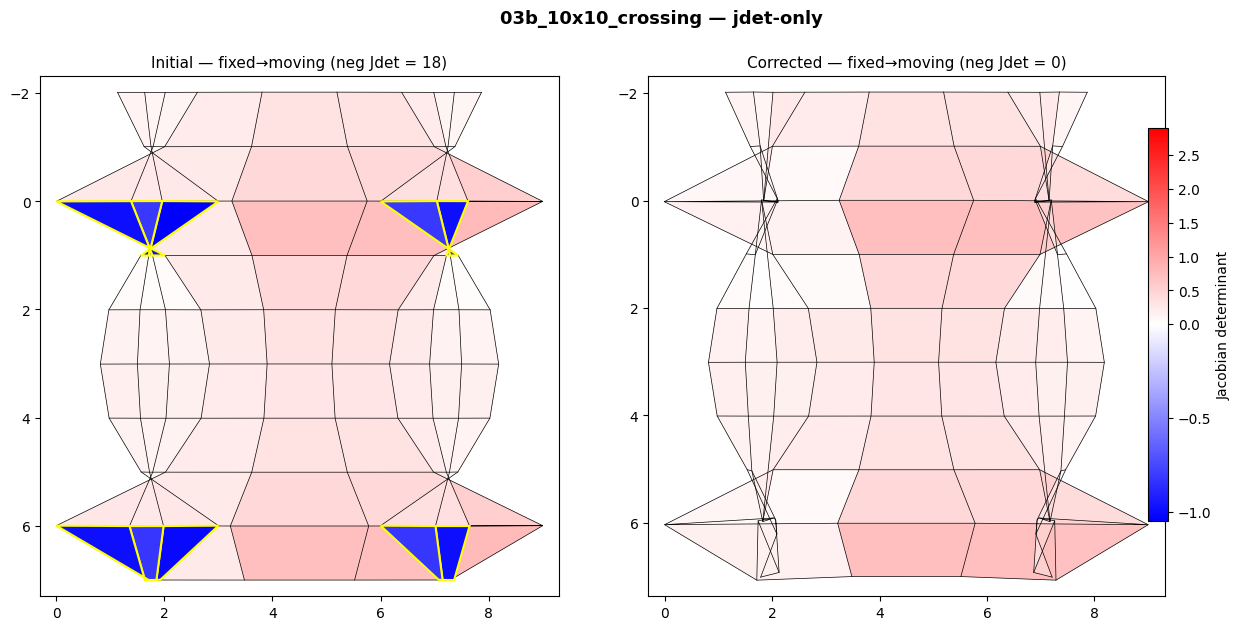

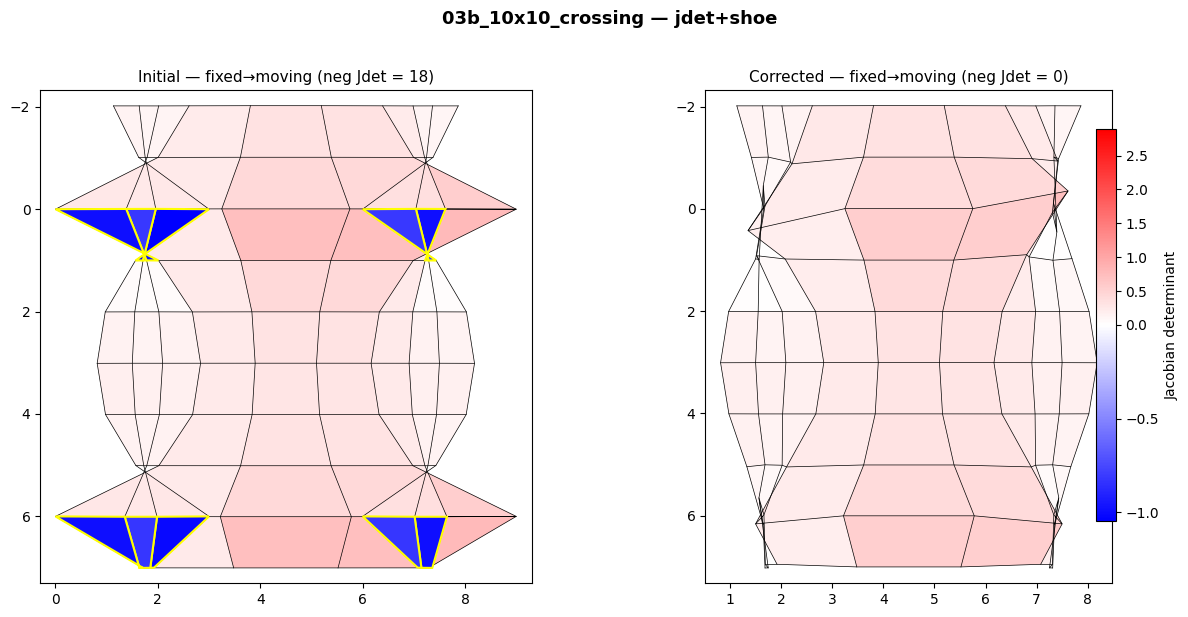

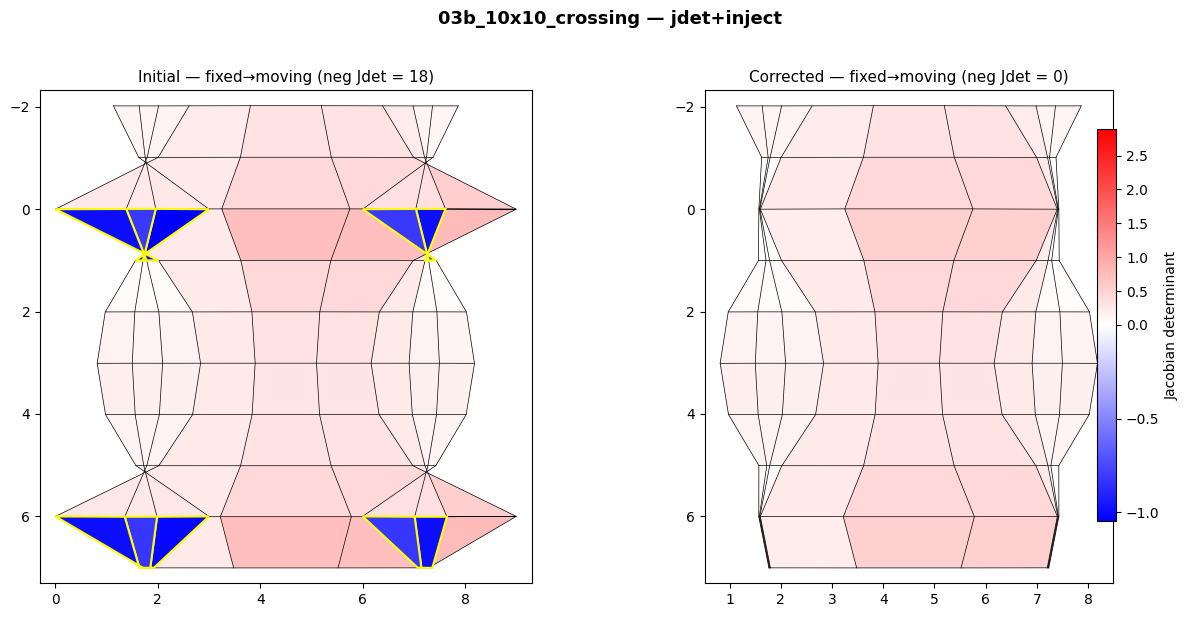

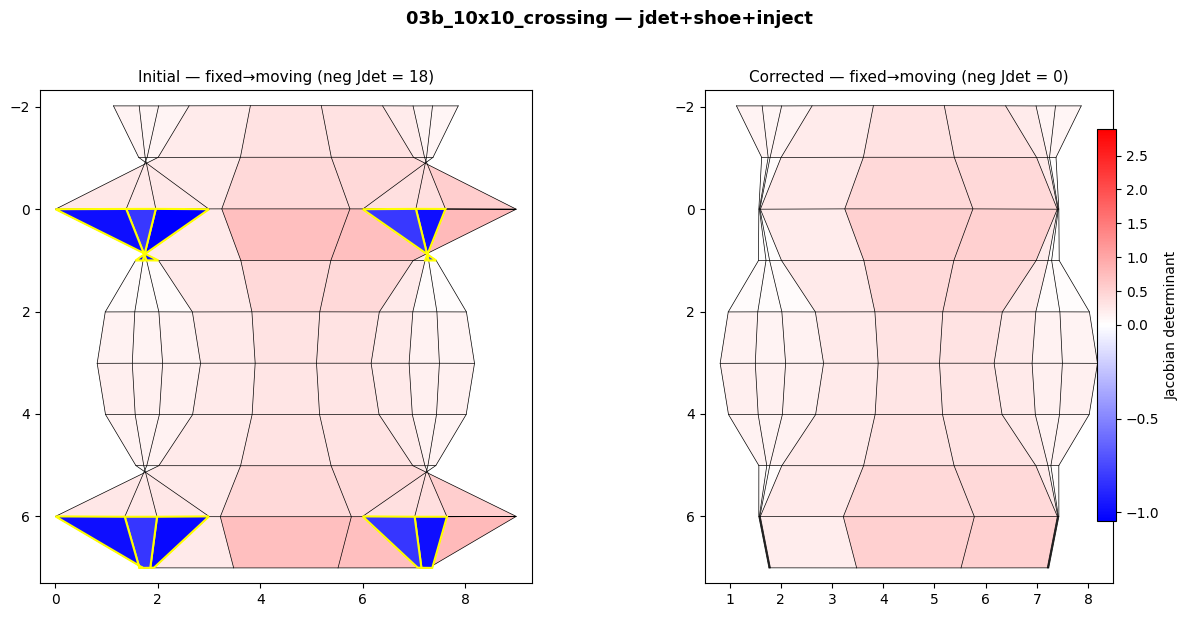


  03c_20x20_opposite  |  shape=(20, 20)
  [initial]  neg_jdet=24  min_jdet=-1.0658  neg_shoe=22  min_shoe=-0.7914  min_h=-1.5895  min_v=+1.0000
[init] Grid 20x20  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 36  |  min Jdet: -1.414921
[iter    1]  parallel  batch=4  neg_pixels=24  windows=9-9
         -> neg_jdet     2  min_jdet -0.041023  L2 3.8326
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 20 x 20
  Iterations       : 1  (serial=0, parallel=1)
  Neg-Jdet     36 ->     2
  Min Jdet  -1.414921 -> -0.041023
  L2 error         : 3.832628
  Time             : 0.93s
  [jdet-only           ]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=16  min_shoe=-0.8185  min_h=-1.5733  min_v=+0.2109  mono=FAIL  L2=3.8326
  Time: 0.93s
[init] Grid 20x20  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 36  

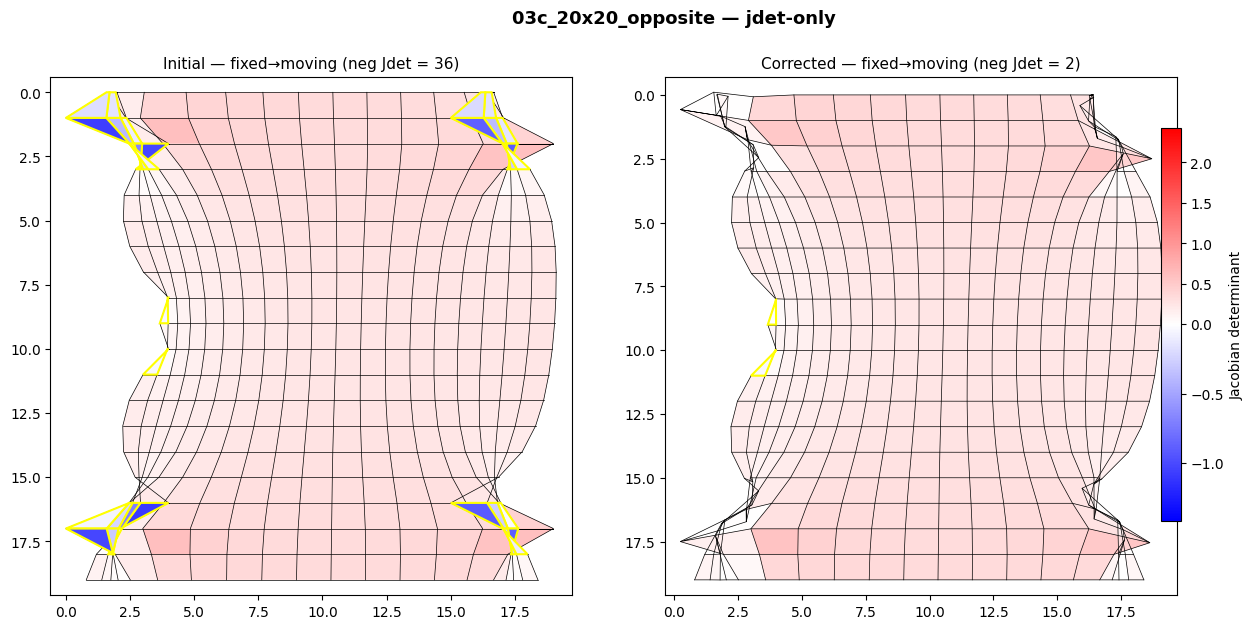

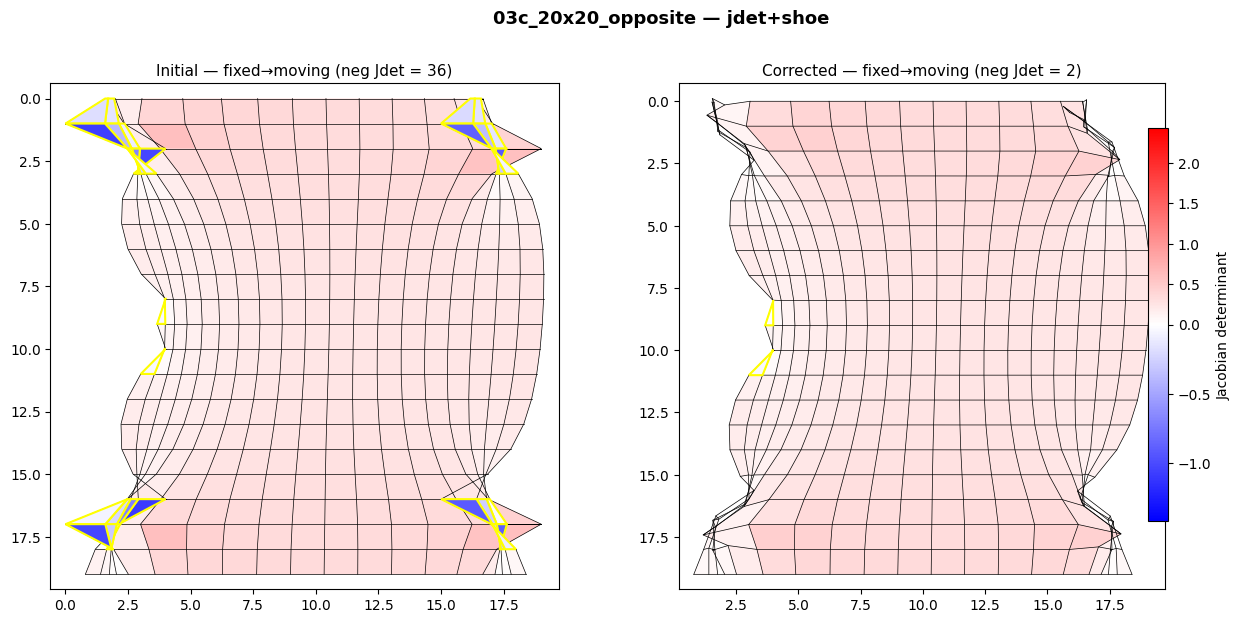

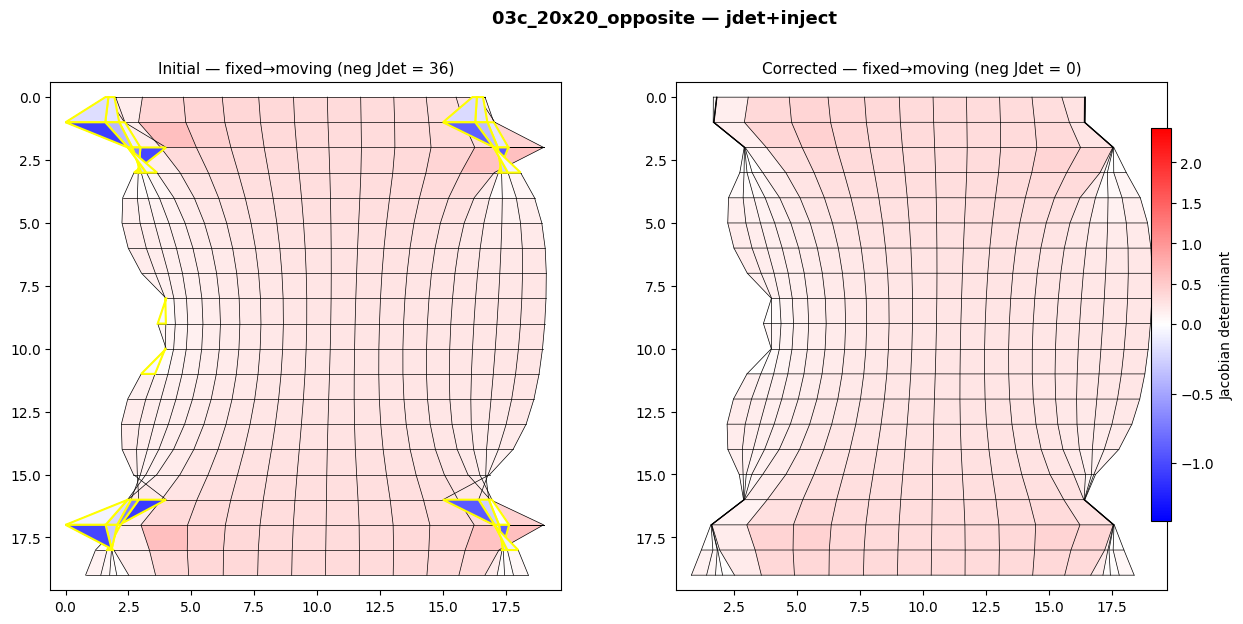

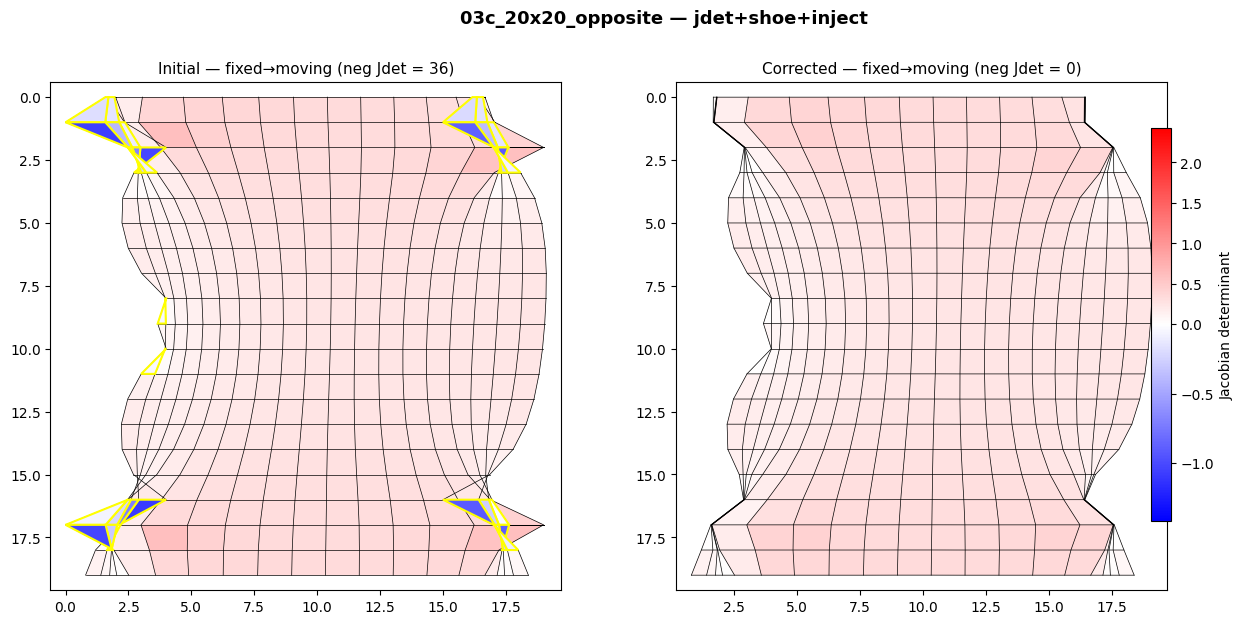


  03d_20x20_crossing  |  shape=(20, 20)
  [initial]  neg_jdet=24  min_jdet=-1.0155  neg_shoe=60  min_shoe=-0.5990  min_h=-1.4877  min_v=+0.8192
[init] Grid 20x20  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 30  |  min Jdet: -1.015545
[iter    1]  parallel  batch=4  neg_pixels=24  windows=9-9
         -> neg_jdet    12  min_jdet -0.898971  L2 5.0618
[iter    2]  serial  fix (  2,  8)  neg_pixels=10
         -> neg_jdet     3  min_jdet -0.795790  L2 5.9474  win 19  sub-iters 5
[iter    3]  serial  fix (  8, 17)  neg_pixels=4
         -> neg_jdet     0  min_jdet +0.009214  L2 6.1588  win 11  sub-iters 1
[iter    4]  serial  fix ( 15, 17)  neg_pixels=2
         -> neg_jdet     0  min_jdet +0.009821  L2 6.1901  win 11  sub-iters 1
[iter    5]  serial  fix (  2, 17)  neg_pixels=1
         -> neg_jdet     2  min_jdet -0.448238  L2 6.0485  win 13  sub-iters 2
[iter    6]  serial  fix (  2,  8)  neg_pixels=2
         -> neg_jdet     0  min_jdet +0

In [ ]:
for case_key in SYNTHETIC_CASES:
    deformation, msample, fsample = make_deformation(case_key)
    results = compare(case_key, deformation)

## Summary table

Collect results for all cases side-by-side.

In [ ]:
import pandas as pd

rows = []
for case_key in SYNTHETIC_CASES:
    deformation, _, _ = make_deformation(case_key)

    for label, kwargs in MODES:
        phi = iterative_parallel(
            deformation.copy(), verbose=0, threshold=JDET_THRESHOLD, **kwargs,
        )
        jac = jacobian_det2D(phi)
        shoe = shoelace_det2D(phi)
        h, v = _monotonicity_diffs_2d(phi[0], phi[1])
        phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
        l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
        rows.append(dict(
            case=case_key, mode=label,
            neg_jdet=int((jac[0, 1:-1, 1:-1] <= 0).sum()),
            min_jdet=float(jac[0, 1:-1, 1:-1].min()),
            neg_shoe=int((shoe[0, 1:-1, 1:-1] <= 0).sum()),
            min_shoe=float(shoe[0, 1:-1, 1:-1].min()),
            min_h_mono=float(h[1:-1, 1:-1].min()),
            min_v_mono=float(v[1:-1, 1:-1].min()),
            L2=l2,
        ))

df = pd.DataFrame(rows)
df.style.format({
    "min_jdet": "{:+.4f}", "min_shoe": "{:+.4f}",
    "min_h_mono": "{:+.4f}", "min_v_mono": "{:+.4f}", "L2": "{:.4f}",
})